<a href="https://colab.research.google.com/github/victorealeal/mod-1---regress-o/blob/main/Profissao_Cientista_de_Dados_M13_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [20]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [11]:
media_por_categoria = (
    df.groupby("Categoria")["Preco_Normal"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Preco_Normal": "Media"})
)
print("=== MÉDIA POR CATEGORIA ===")
print(media_por_categoria.to_string(index=False))


=== MÉDIA POR CATEGORIA ===
                 Categoria   Media
belleza-y-cuidado-personal 1783.56
        comidas-preparadas 3095.04
                congelados 2108.04
                    frutas 1724.47
      instantaneos-y-sopas  765.49
                   lacteos 2385.22
                  verduras 1343.30


In [12]:
mediana_por_categoria = (
    df.groupby("Categoria")["Preco_Normal"]
    .median()
    .round(2)
    .reset_index()
    .rename(columns={"Preco_Normal": "Mediana"})
)
print("=== MEDIANA POR CATEGORIA ===")
print(mediana_por_categoria.to_string(index=False))


=== MEDIANA POR CATEGORIA ===
                 Categoria  Mediana
belleza-y-cuidado-personal   1569.0
        comidas-preparadas   3290.0
                congelados   1519.0
                    frutas   1195.0
      instantaneos-y-sopas    439.0
                   lacteos    989.0
                  verduras   1180.0


Digite aqui as categorias: belleza-y-cuidado-personal; comidas-preparadas; congeladas; frutas; instantaneos-y-sopas; lacteos; verduras.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [18]:
desvio_por_categoria = (
    df.groupby("Categoria")["Preco_Normal"]
    .std()
    .round(2)
    .reset_index()
    .rename(columns={"Preco_Normal": "Desvio_Padrao"})
    .sort_values("Desvio_Padrao", ascending=False)
)

print("=== DESVIO PADRÃO POR CATEGORIA (maior → menor) ===")
print(desvio_por_categoria.to_string(index=False))

categoria_maior_desvio = desvio_por_categoria.iloc[0]["Categoria"]
print(f"\n🏆 Categoria com MAIOR desvio padrão: {categoria_maior_desvio}")

=== DESVIO PADRÃO POR CATEGORIA (maior → menor) ===
                 Categoria  Desvio_Padrao
                   lacteos        3925.82
belleza-y-cuidado-personal        2210.04
                congelados        2111.54
        comidas-preparadas        2019.91
                    frutas        1639.15
      instantaneos-y-sopas        1170.23
                  verduras        1012.70

🏆 Categoria com MAIOR desvio padrão: lacteos


Digite nesse campo o comportamento que você identificou - lacteos tem maior desvio, verduras tem menor desvio.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

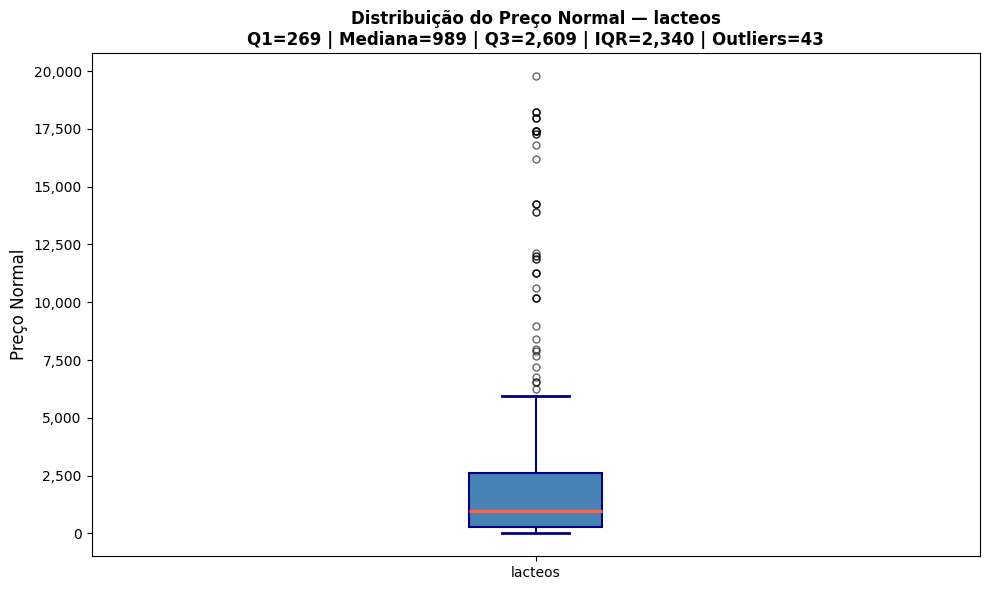


📊 Estatísticas — lacteos
count       447.00
mean      2,385.22
std       3,925.82
min           0.00
25%         269.00
50%         989.00
75%       2,609.00
max      19,788.00
Name: Preco_Normal, dtype: object

⚠️  Total de outliers identificados: 43


In [21]:
# ── Filtrando apenas a categoria com maior desvio ─────────────────────────────
df_categoria = df.loc[df["Categoria"] == categoria_maior_desvio, "Preco_Normal"]

# ── Boxplot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    df_categoria.dropna(),
    vert=True,
    patch_artist=True,
    notch=False,
    boxprops=dict(facecolor="steelblue", color="navy", linewidth=1.5),
    medianprops=dict(color="tomato", linewidth=2.5),
    whiskerprops=dict(color="navy", linewidth=1.5),
    capprops=dict(color="navy", linewidth=2),
    flierprops=dict(marker="o", color="tomato", markersize=5, alpha=0.6)
)

# Estatísticas para anotação
q1  = df_categoria.quantile(0.25)
q3  = df_categoria.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
n_outliers = ((df_categoria < lim_inf) | (df_categoria > lim_sup)).sum()

ax.set_title(
    f"Distribuição do Preço Normal — {categoria_maior_desvio}\n"
    f"Q1={q1:,.0f} | Mediana={df_categoria.median():,.0f} | "
    f"Q3={q3:,.0f} | IQR={iqr:,.0f} | Outliers={n_outliers}",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Preço Normal", fontsize=12)
ax.set_xticklabels([categoria_maior_desvio])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

print(f"\n📊 Estatísticas — {categoria_maior_desvio}")
print(df_categoria.describe().apply(lambda x: f"{x:,.2f}"))
print(f"\n⚠️  Total de outliers identificados: {n_outliers}")

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

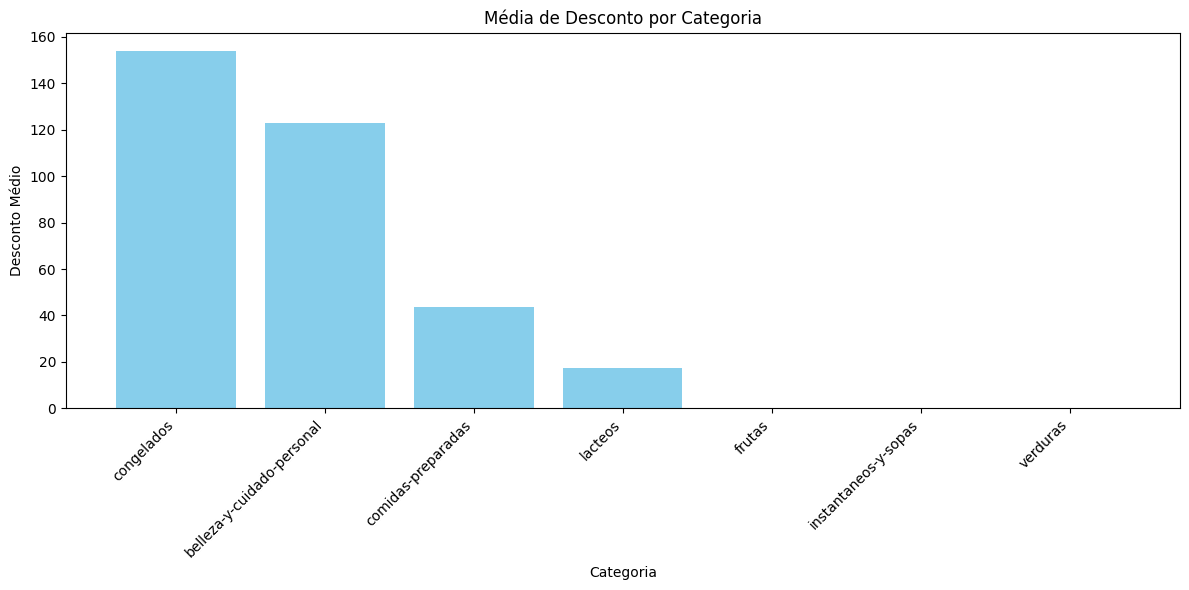

In [25]:
# Agrupando a média de descontos por categoria
discounts_by_category = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=False).reset_index()

# Plotando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(discounts_by_category['Categoria'], discounts_by_category['Desconto'], color='skyblue')
plt.title('Média de Desconto por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Desconto Médio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [26]:
df_grupo = (
    df.groupby(["Categoria", "Marca"])["Desconto"]
    .agg(["mean", "count"])
    .round(2)
    .reset_index()
    .rename(columns={"mean": "Media_Desconto", "count": "Quantidade"})
    .sort_values(["Categoria", "Media_Desconto"], ascending=[True, False])
)

# Usamos 'Quantidade' para o tamanho das áreas (values)
# e 'Media_Desconto' para a cor, evitando o erro de divisão por zero.
fig = px.treemap(
    df_grupo,
    path=["Categoria", "Marca"],
    values="Quantidade",
    color="Media_Desconto",
    color_continuous_scale="Blues",
    title="Média de Desconto por Categoria e Marca (Tamanho = Qtd de Produtos)",
    hover_data={"Media_Desconto": ":.2f", "Quantidade": True},
)

fig.update_layout(
    title_font_size=18,
    coloraxis_colorbar=dict(title="Média Desconto"),
    margin=dict(t=60, l=10, r=10, b=10)
)

fig.show()

# **Resumo Final do Projeto: Insights e Conclusões**

Após a análise exploratória e estatística da base de dados de supermercado, destacam-se os seguintes pontos:

### 1. Disparidade de Preços e Dispersão
*   A categoria **Lácteos** apresentou o maior desvio padrão (**3.925,82**) e a maior quantidade de **outliers (43)**. Isso indica que, embora a maioria dos produtos tenha preços acessíveis, existem itens (como packs de leite) que elevam drasticamente a média em relação à mediana.
*   Categorias como **Instantâneos e Sopas** possuem a menor média de preço, sendo os itens mais populares e estáveis do dataset.

### 2. Estratégia de Descontos
*   **Foco em Volume:** As categorias de **Congelados** e **Beleza e Cuidado Pessoal** são as que recebem os maiores descontos médios. Isso sugere uma estratégia para aumentar o giro desses produtos.
*   **Ausência de Promoções:** Notavelmente, as categorias de **Frutas, Verduras e Instantâneos** não apresentaram descontos no período analisado, operando sempre com o preço normal.

### 3. Dinâmica entre Preço e Desconto
*   A correlação global entre o Preço Normal e o Desconto é **fraca e negativa (-0.19)**. Isso significa que o supermercado não aplica descontos proporcionais ao preço; produtos caros não ganham descontos necessariamente maiores.
*   Por categoria, a correlação negativa é mais acentuada em **Congelados (-0.52)**, sugerindo que nesta seção, os descontos são aplicados de forma mais agressiva em itens de menor valor unitário.

### 4. Visualização de Mercado
*   O Treemap revelou que certas marcas em **Beleza** (como Rexona e Oral Fresh) dominam os valores de desconto, enquanto em Lácteos, o desconto é distribuído de forma muito mais tímida entre as marcas.